# Task 1: Explore the Dataset

In this task, we load the California Housing dataset and explore its structure.
We examine the dataset shape, preview the data, analyze basic statistics,
identify correlations with the target variable (MedHouseVal), and visualize
the distribution of house prices.

Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic Statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        

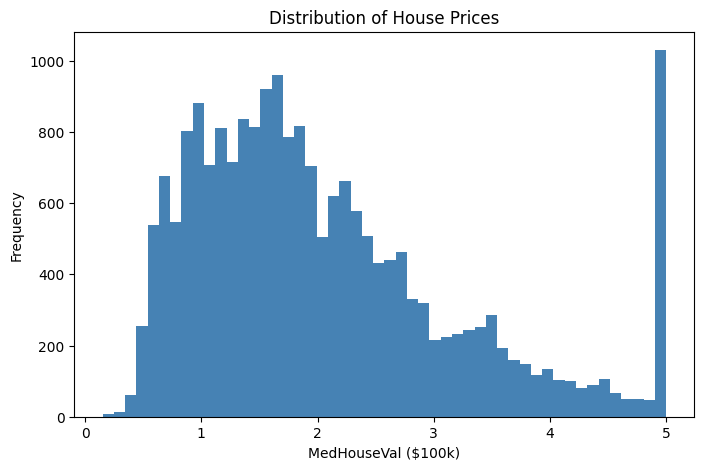

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Display dataset info
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe().round(3))

# Correlation with target
print("\nCorrelation with MedHouseVal:")
corr = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(corr)

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue')
plt.title("Distribution of House Prices")
plt.xlabel("MedHouseVal ($100k)")
plt.ylabel("Frequency")
plt.show()

Task 1 Conclusion:

The dataset contains 20,640 samples and 9 columns. The feature MedInc
(median income) has the strongest correlation with house prices, indicating
it is the most important predictor. The distribution of the target variable
is slightly skewed and appears capped around 5.0, meaning higher house prices
are limited. Overall, the dataset is large and suitable for training a regression model.

# Task 2: Simple Linear Regression

In this task, we build a simple linear regression model using only one feature
(MedInc) to predict house prices. We split the data into training and testing sets,
train the model, extract the learned equation, and visualize the regression line.

Training samples: 16512
Testing samples: 4128

Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + (0.4446)


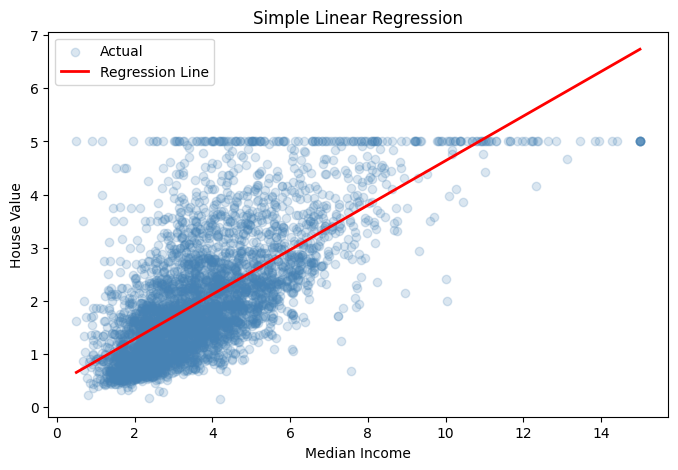

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Use only MedInc as feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print equation
slope = model_simple.coef_[0]
intercept = model_simple.intercept_

print(f"\nSlope (w1): {slope:.4f}")
print(f"Intercept (w0): {intercept:.4f}")
print(f"Equation: y = {slope:.4f} * MedInc + ({intercept:.4f})")

# Plot regression line
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.2, color='steelblue', label='Actual')

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1,1))

plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

Task 2 Conclusion:

The simple linear regression model was trained using MedInc as the only feature.
The model learned a positive slope, indicating that as median income increases,
house prices also increase. The regression line shows a clear upward trend, but
there is still significant spread in the data, meaning one feature alone is not
enough to fully predict house prices accurately.

# Task 3: Evaluate the Simple Linear Regression Model

In this task, we evaluate the performance of the simple linear regression model
using different regression metrics. We calculate MSE, RMSE, MAE, and R² to
measure the model’s prediction accuracy. We also visualize predicted vs actual
values and analyze residual errors.

=== Simple Linear Regression Evaluation ===
MSE: 0.7091
RMSE: 0.8421
MAE: 0.6299
R^2: 0.4589


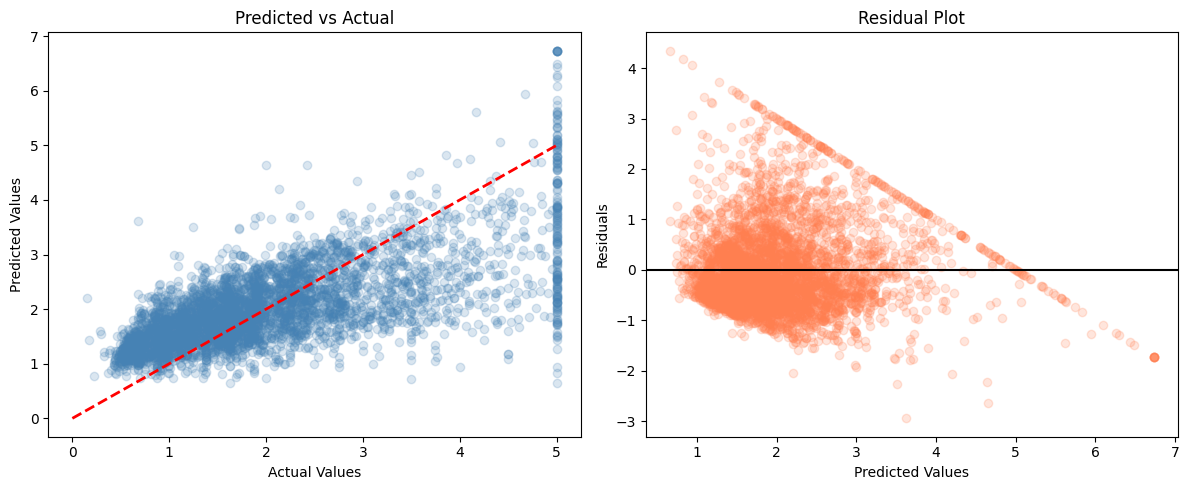

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression Evaluation ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

# --------------------------
# Plot 1: Predicted vs Actual
# --------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_simple, alpha=0.2, color='steelblue')
plt.plot([0,5], [0,5], 'r--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")

# --------------------------
# Plot 2: Residuals
# --------------------------
residuals = y_test - y_pred_simple

plt.subplot(1,2,2)
plt.scatter(y_pred_simple, residuals, alpha=0.2, color='coral')
plt.axhline(y=0, color='black')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

Task 3 Conclusion:

The model’s performance shows that the prediction error is still relatively high,
as indicated by the RMSE and MAE values. The R² score suggests that the model
explains only part of the variance in house prices. The predicted vs actual plot
shows that predictions deviate more at higher values, and the residual plot
indicates that errors are not perfectly random. This confirms that using only
one feature is not sufficient for accurate predictions.

# Task 4: Multiple Linear Regression

In this task, we build a multiple linear regression model using all available
features to predict house prices. We apply feature scaling using a pipeline,
train the model, evaluate its performance, and analyze which features are
most important.

=== Multiple Linear Regression ===
RMSE: 0.7456
R^2: 0.5758

Feature Importance:
      Feature  Coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


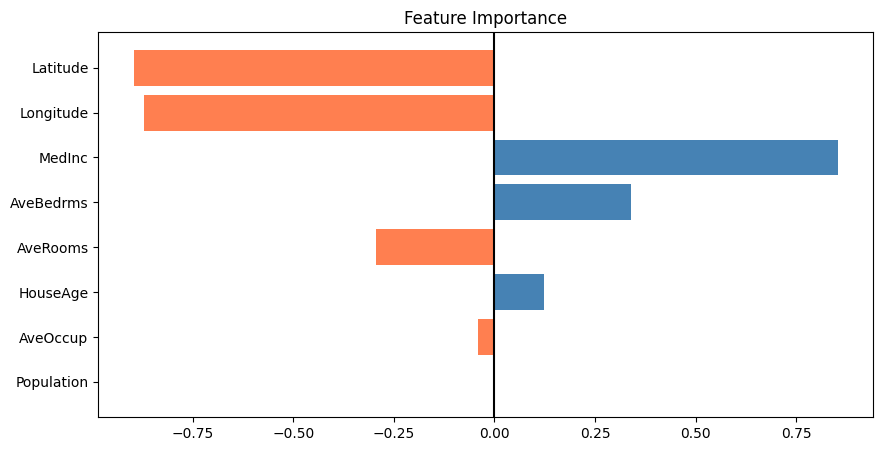

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Create pipeline (scaling + model)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train
pipe_lr.fit(X_train, y_train)

# Predict
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("=== Multiple Linear Regression ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f}")

# --------------------------
# Feature Importance
# --------------------------
lr_model = pipe_lr.named_steps['lr']
feature_names = df.drop(columns=['MedHouseVal']).columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nFeature Importance:")
print(coef_df)

# Plot feature importance
plt.figure(figsize=(10,5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black')
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Task 4 Conclusion:

The multiple linear regression model moderatly improved performance compared
to the simple model, as shown by a higher R² score and lower RMSE. Using all
features allows the model to capture more information about house prices.
MedInc remains the most important feature, while other features also contribute
to the prediction. This confirms that multiple features are necessary for
better accuracy.

# Task 5: Polynomial Regression

In this task, we explore polynomial regression to capture non-linear
relationships between median income and house prices. We test different
polynomial degrees (1, 2, and 3) and compare their performance using R²
and RMSE. We also visualize how the regression curve changes with degree.

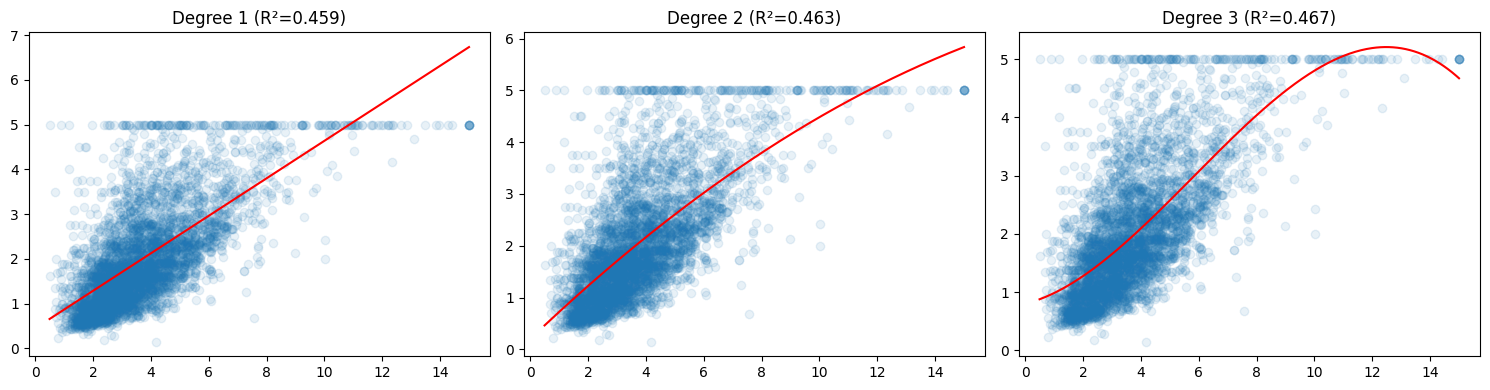

Polynomial Results:
Degree 1: R²=0.4589, RMSE=0.8421
Degree 2: R²=0.4633, RMSE=0.8386
Degree 3: R²=0.4671, RMSE=0.8356


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

degrees = [1, 2, 3]
results = {}

plt.figure(figsize=(15,4))

for i, degree in enumerate(degrees):

    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    pipe_poly.fit(X_train, y_train)
    y_pred = pipe_poly.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[degree] = (r2, rmse)

    # Plot
    plt.subplot(1,3,i+1)
    plt.scatter(X_test, y_test, alpha=0.1)

    x_line = np.linspace(X_test.min(), X_test.max(), 300).reshape(-1,1)
    y_line = pipe_poly.predict(x_line)

    plt.plot(x_line, y_line, color='red')
    plt.title(f"Degree {degree} (R²={r2:.3f})")

plt.tight_layout()
plt.show()

# Print results
print("Polynomial Results:")
for d, (r2, rmse) in results.items():
    print(f"Degree {d}: R²={r2:.4f}, RMSE={rmse:.4f}")

Task 5 Conclusion:

Polynomial regression provides only a slight improvement over the linear model,
as seen in the small increase in R² and decrease in RMSE. This suggests that
the relationship between median income and house prices is mostly linear.
Higher-degree models, such as degree 3, show signs of overfitting, especially
at extreme values. Therefore, increasing model complexity does not significantly
improve performance in this case.

# Task 6: Regularization (Ridge, Lasso, ElasticNet)

In this task, we apply regularization techniques to improve model generalization
and reduce overfitting. We train Ridge, Lasso, and ElasticNet regression models,
compare their performance using RMSE and R², and analyze how regularization
affects model accuracy.

In [21]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = (rmse, r2)

# Print results
print("=== Regularization Results ===")
for name, (rmse, r2) in results.items():
    print(f"{name}: RMSE={rmse:.4f}, R²={r2:.4f}")

=== Regularization Results ===
Ridge: RMSE=0.8421, R²=0.4589
Lasso: RMSE=0.8420, R²=0.4590
ElasticNet: RMSE=0.8420, R²=0.4590


Task 6 Conclusion:

Regularization techniques such as Ridge, Lasso, and ElasticNet help control
model complexity and reduce overfitting. The results show that these models
perform similarly to standard linear regression, with slight differences in
RMSE and R². Regularization can improve model stability and generalization,
especially when dealing with multiple features.

Final Reflection:

In this lab, we explored different regression techniques to predict house prices.
We started with simple linear regression, which showed limited performance due to
using only one feature. Multiple linear regression improved the results by using
all available features. Polynomial regression showed that the relationship is mostly
linear, with only slight non-linear patterns. Regularization techniques did not
significantly improve performance, indicating that overfitting was not a major issue.
Overall, the lab demonstrated how model complexity affects performance and the
importance of selecting appropriate features.